# Completed exercise using numpy, pandas, clean data, data transformation and data visualization

# First Taks

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
# Load titanic data set
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

In [3]:
# Inspect the data
print(df.info())
print(df.describe())

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB
None
       PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  714.000000  891.000000   
mean    446.000000    0.383838    2.308642   29.699118    0.523008   
std     257.353842    0.486592    0.836071  

In [4]:
# Handle missing values
df["Age"] = df["Age"].fillna(df["Age"].median())
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

# Remove duplicate
df = df.drop_duplicates()

# Filter data: Passenger in first class
first_class = df[df["Pclass"] == 1]
print(f"First class passenger: \n {first_class}")


First class passenger: 
      PassengerId  Survived  Pclass  \
1              2         1       1   
3              4         1       1   
6              7         0       1   
11            12         1       1   
23            24         1       1   
..           ...       ...     ...   
871          872         1       1   
872          873         0       1   
879          880         1       1   
887          888         1       1   
889          890         1       1   

                                                  Name     Sex   Age  SibSp  \
1    Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
3         Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
6                              McCarthy, Mr. Timothy J    male  54.0      0   
11                            Bonnell, Miss. Elizabeth  female  58.0      0   
23                        Sloper, Mr. William Thompson    male  28.0      0   
..                                          

## Task 2 Visualization

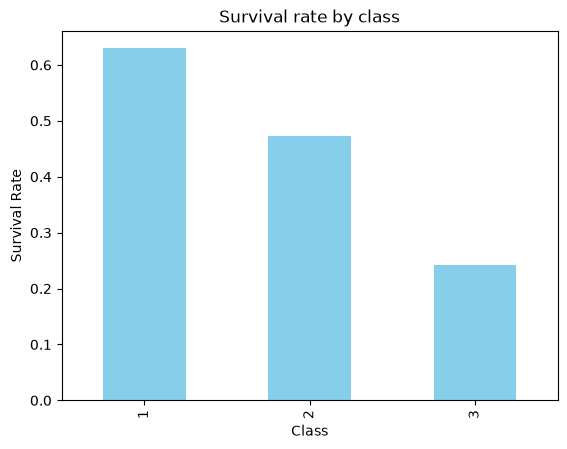

In [7]:
# Bar Chart: Survival rate by class
survival_by_class = df.groupby("Pclass")["Survived"].mean()
survival_by_class.plot(kind="bar", color="skyblue")
plt.title("Survival rate by class")
plt.xlabel("Class")
plt.ylabel("Survival Rate")
plt.show()

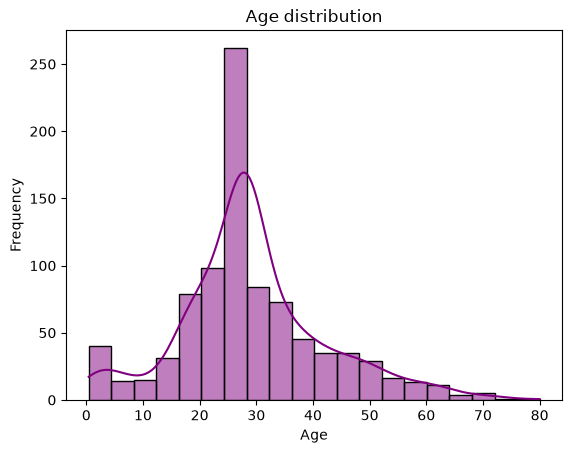

In [8]:
# Histogram: Age distribution
sns.histplot(df["Age"], kde=True, bins=20, color="purple")
plt.title("Age distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

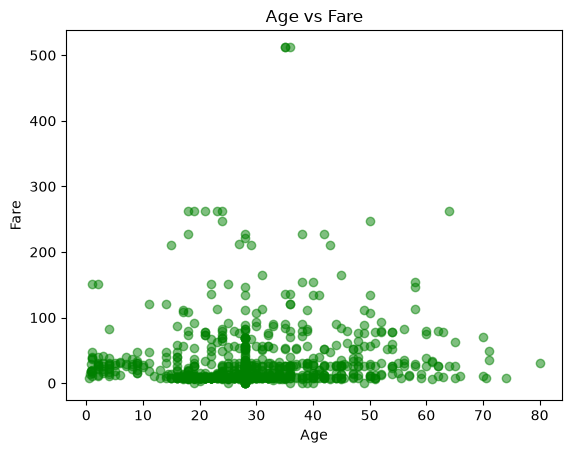

In [9]:
# Scatter Plo: Age vs Fare
plt.scatter(df["Age"], df["Fare"], alpha=0.5, color="green")
plt.title("Age vs Fare")
plt.xlabel("Age")
plt.ylabel("Fare")
plt.show()

## Task 4: Summarize findings in a report

1. Overview
    - Dataset contains 891 rows and 12 columns.
    - Missing Values handle for 'Age' (filled with median) and 'Embarked' (filled with mode).

2. Key Insights:
    - Survival rates are highest for first class passengers(62%) and lowest for third-class customer (24%)
    - Majority  of passengers are aged between 20-40 years
    - A positive correlation exists between fare and survival

3. Visual Insights:
    - Screenshots

---
---

# Proyectos de Portafolio — Data Science Essentials

> Estos ejercicios están diseñados para publicar en LinkedIn. Cada uno simula un problema real empresarial. No hay pasos técnicos directos — debes pensar primero como Data Scientist: **¿qué necesita saber el negocio? ¿cómo llego a esa respuesta con los datos?**

---

## Proyecto 1: Análisis de la Fuerza Laboral y Niveles Salariales
### *"¿Qué factores realmente determinan si un trabajador gana más de $50K?"*

**Contexto empresarial:**
Una consultora de recursos humanos está asesorando a varias empresas sobre sus estrategias de compensación. Necesitan entender qué perfil socioeconómico y laboral predice el nivel salarial de un empleado: ¿es la educación el factor más determinante? ¿Cuántas horas a la semana trabaja alguien antes de cruzar ese umbral? ¿Existen brechas por género u ocupación que las empresas deberían atender?

**Dataset:** US Census Income — 32,560 registros, 15 variables
```
https://raw.githubusercontent.com/dsrscientist/dataset1/master/census_income.csv
```
Columnas clave: `Age`, `Workclass`, `Education`, `Education_num`, `Occupation`, `Sex`, `Hours_per_week`, `Native_country`, `Income`

**Preguntas que debe responder tu análisis:**
- ¿Existe un perfil claro del trabajador que gana más de $50K? ¿Qué tienen en común?
- ¿La educación por sí sola explica el nivel salarial, o hay variables más determinantes?
- ¿Qué ocupaciones concentran más trabajadores de altos ingresos?
- ¿Existe brecha salarial significativa entre géneros dentro del mismo nivel educativo?
- ¿Cuántas horas semanales trabaja en promedio alguien que supera el umbral de $50K?

**Entregables del notebook:**
1. Limpieza y auditoría de calidad de datos (¿hay nulos, duplicados, espacios en blanco en categorías?)
2. EDA univariado: distribución de cada variable clave (`Age`, `Education_num`, `Hours_per_week`)
3. EDA bivariado: relación entre cada variable y la columna `Income`
4. Mapa de correlación entre todas las variables numéricas
5. Al menos 5 visualizaciones con títulos e insights escritos debajo de cada una
6. Sección final: **"3 recomendaciones a la consultora de RRHH"** basadas en tus hallazgos

**Criterio LinkedIn:** Tu post debe poder responder: *"Analicé los datos de 32,000 trabajadores del censo de EE.UU. y encontré que [insight sorprendente]. Aquí está lo que los datos dicen sobre qué determina el nivel salarial."*

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- CARGA DE DATOS ---
url = "https://raw.githubusercontent.com/dsrscientist/dataset1/master/census_income.csv"
df_census = pd.read_csv(url)

# Nota: algunas columnas categóricas tienen espacios al inicio — strip() será necesario
print(f"Shape: {df_census.shape}")
print(f"\nColumnas: {df_census.columns.tolist()}")
print(f"\nDistribución de Income (variable target):")
print(df_census["Income"].value_counts())
print(f"\nPrimeras filas:")
df_census.head()

# --- DESDE AQUÍ ES TU ANÁLISIS ---
# Recuerda: primero entiende los datos, luego limpia, luego visualiza, luego concluye

---

## Proyecto 2: Reporte Ejecutivo de la Pandemia COVID-19
### *"¿Qué países respondieron mejor y qué factores marcaron la diferencia?"*

**Contexto empresarial:**
Una ONG internacional de salud pública necesita un reporte ejecutivo para presentar ante gobiernos de América Latina. El reporte debe identificar qué países de la región manejaron mejor la pandemia, si la riqueza del país influyó en la respuesta, y cuál fue el impacto real de la vacunación en la mortalidad.

Este es un dataset **real y masivo** — más de 300,000 filas con datos de +200 países desde 2020 hasta 2024.

**Dataset:** Our World in Data — COVID-19 (~380,000 registros)
```
https://raw.githubusercontent.com/owid/covid-19-data/master/public/data/owid-covid-data.csv
```
Columnas clave: `location`, `date`, `total_cases`, `new_cases`, `total_deaths`, `new_deaths`, `total_vaccinations`, `people_fully_vaccinated_per_hundred`, `gdp_per_capita`, `human_development_index`, `continent`

**Preguntas que debe responder tu análisis:**
- ¿Cuándo ocurrió el pico de casos y muertes en América Latina? ¿Fue simultáneo en todos los países?
- ¿Existe correlación entre el PIB per cápita de un país y su tasa de vacunación?
- ¿Los países con mayor índice de desarrollo humano tuvieron menos muertes por millón?
- ¿Qué país de América Latina tuvo la recuperación más rápida tras su pico máximo?
- Al comparar el período pre-vacuna vs post-vacuna, ¿qué cambió en la tasa de mortalidad?

**Entregables del notebook:**
1. Estrategia de limpieza para un dataset de esta escala (¿cómo manejas 380k filas eficientemente?)
2. Filtrado y análisis enfocado en América Latina (mínimo 5 países)
3. Serie de tiempo: evolución de casos y muertes con anotaciones en eventos clave
4. Análisis de correlación: riqueza vs respuesta sanitaria
5. Comparación visual antes/después de la vacunación masiva
6. Dashboard final: 4 gráficas en un solo `plt.subplot` listo para captura de pantalla

**Reto adicional:** Usa `rolling(7).mean()` para suavizar la curva de nuevos casos diarios y explica por qué esto es importante en análisis epidemiológico.

**Criterio LinkedIn:** *"Analicé 4 años de datos de COVID-19 en 200 países. Esto es lo que los datos revelan sobre qué determinó la diferencia entre países."*

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- CARGA DE DATOS ---
# Advertencia: este dataset pesa ~100MB. La primera carga puede tardar 1-2 minutos.
url = "https://raw.githubusercontent.com/owid/covid-19-data/master/public/data/owid-covid-data.csv"

# Tip de rendimiento: solo carga las columnas que necesitas
cols = ["location", "date", "continent", "new_cases", "new_deaths",
        "total_cases", "total_deaths", "total_vaccinations",
        "people_fully_vaccinated_per_hundred", "gdp_per_capita",
        "human_development_index", "total_deaths_per_million"]

df_covid = pd.read_csv(url, usecols=cols, parse_dates=["date"])

print(f"Shape: {df_covid.shape}")
print(f"Países únicos: {df_covid['location'].nunique()}")
print(f"Rango de fechas: {df_covid['date'].min()} → {df_covid['date'].max()}")
df_covid.head()

# --- DESDE AQUÍ ES TU ANÁLISIS ---

---

## Proyecto 3: Optimización de Ventas para una Cadena Retail Global
### *"¿Dónde está dejando dinero sobre la mesa nuestra empresa?"*

**Contexto empresarial:**
Una cadena retail con operaciones en Europa recibe un reporte de su sistema de ventas con más de 500,000 transacciones de un año. La dirección financiera necesita entender qué productos y mercados son realmente rentables, identificar clientes de alto valor, y detectar patrones estacionales para optimizar el inventario del próximo año.

Este es el clásico **Online Retail Dataset de UCI** — un benchmark real en ciencia de datos empresarial.

**Dataset:** UCI Online Retail — ~541,000 transacciones (2010-2011)

Descarga desde Kaggle (requiere cuenta gratuita):
```
https://www.kaggle.com/datasets/mashlyn/online-retail-ii-uci
```
O carga directamente el Excel de UCI (puede tardar):
```python
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00352/Online%20Retail.xlsx"
df = pd.read_excel(url)
```

Columnas: `InvoiceNo`, `StockCode`, `Description`, `Quantity`, `InvoiceDate`, `UnitPrice`, `CustomerID`, `Country`

**Preguntas que debe responder tu análisis:**
- ¿Qué países generan más revenue? ¿La concentración es saludable para el negocio?
- ¿Hay transacciones con `Quantity` negativa? ¿Qué representan y cómo deben tratarse?
- ¿Qué productos tienen el mayor volumen de devoluciones?
- ¿Existe un patrón horario o día de la semana en las compras?
- ¿Cuál es el valor promedio de una transacción y cómo varía por país?

**Entregables del notebook:**
1. Auditoría completa de calidad: facturas canceladas, precios en cero, customers sin ID
2. Ingeniería de características: crea la columna `Revenue = Quantity * UnitPrice`
3. Análisis de Pareto: ¿el 20% de los productos genera el 80% del revenue?
4. Serie de tiempo mensual de ventas con detección de estacionalidad
5. Top 10 productos y Top 10 países por revenue con visualización
6. Segmentación simple de clientes por revenue total (sin ML — solo con `cut` o `qcut`)

**Reto adicional (concepto nuevo — RFM):** Investiga qué es el análisis RFM (Recency, Frequency, Monetary). Calcula estas 3 métricas por cliente e identifica cuáles son tus "mejores clientes". Este concepto es estándar en marketing analytics.

**Criterio LinkedIn:** *"Analicé 540,000 transacciones de retail y apliqué análisis RFM para segmentar clientes. Resultados que cambiarían la estrategia de marketing."*

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- OPCIÓN A: Cargar desde UCI (Excel, puede tardar 2-3 min) ---
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00352/Online%20Retail.xlsx"
# df_retail = pd.read_excel(url)

# --- OPCIÓN B: Si descargaste el CSV desde Kaggle ---
# df_retail = pd.read_csv("Online_Retail.csv", encoding="latin1")

# Descomenta la opción que uses y continúa:
# print(f"Shape: {df_retail.shape}")
# print(f"\nNulos por columna:\n{df_retail.isnull().sum()}")
# df_retail.head()

# --- DESDE AQUÍ ES TU ANÁLISIS ---

---

## Proyecto 4: Análisis del Mercado Inmobiliario
### *"¿Qué determina el precio de una propiedad y dónde conviene invertir?"*

**Contexto empresarial:**
Una firma de inversión inmobiliaria evalúa comprar propiedades para reventa. Antes de tomar decisiones de millones de dólares, el equipo de análisis necesita entender qué características físicas de una propiedad impactan más su precio: ¿el tamaño en metros cuadrados, el número de habitaciones, el piso, o la cantidad de baños? ¿Existe alguna combinación de variables que prediga propiedades infravaloradas?

**Dataset:** Housing Price Dataset — 644 registros, 8 variables
```
https://raw.githubusercontent.com/dsrscientist/dataset1/master/house_price_data.csv
```
Columnas clave: `Sqft`, `Floor`, `TotalFloor`, `Bedroom`, `Living.Room`, `Bathroom`, `Price`

**Preguntas que debe responder tu análisis:**
- ¿Qué variable tiene mayor correlación con el precio? ¿Es el tamaño en Sqft el factor dominante?
- ¿Existe una relación lineal clara entre metros cuadrados y precio, o hay outliers significativos?
- ¿Las propiedades en pisos más altos tienden a costar más? ¿En qué punto del edificio se paga más?
- ¿Cuántos baños o habitaciones tiene la propiedad con mejor relación calidad-precio?
- ¿Hay propiedades que parecen infravaloradas según sus características? ¿Cómo las identificarías?

**Entregables del notebook:**
1. Auditoría de calidad: nulos, duplicados y distribución de cada variable numérica
2. Ingeniería de características: crea `Price_per_Sqft = Price / Sqft` como métrica de eficiencia
3. Mapa de correlación completo entre todas las variables numéricas
4. Análisis de Pareto: ¿qué combinación de características explica el mayor precio?
5. Top propiedades por `Price_per_Sqft` — ¿qué tienen en común las más y menos eficientes?
6. Segmentación por rango de precio con `pd.cut()` — ¿qué características definen cada segmento?

**Reto adicional (concepto nuevo — análisis de residuales):** Ajusta una regresión lineal simple (con `numpy.polyfit`) entre `Sqft` y `Price`. Analiza los residuales: propiedades con residual muy negativo (precio menor al esperado por tamaño) son candidatas a inversión. Este concepto es estándar en valuación inmobiliaria.

**Criterio LinkedIn:** *"Analicé 644 propiedades del mercado inmobiliario. La variable que más predice el precio no es la que pensarías. Aquí está lo que los datos dicen para quien quiera invertir."*

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- CARGA DE DATOS ---
url = "https://raw.githubusercontent.com/dsrscientist/dataset1/master/house_price_data.csv"
df_housing = pd.read_csv(url)

print(f"Shape: {df_housing.shape}")
print(f"\nColumnas disponibles:\n{df_housing.columns.tolist()}")
print(f"\nTipos de datos:\n{df_housing.dtypes}")
print(f"\nEstadísticas descriptivas:")
df_housing.describe()

# --- DESDE AQUÍ ES TU ANÁLISIS ---

---

## Guía de Publicación en LinkedIn

Cuando termines cada proyecto, usa esta estructura para tu post:

**Hook (primera línea — lo más importante):**
> "Analicé [N] registros de [tema] y encontré algo que no esperaba:"

**Cuerpo (3-5 bullets con hallazgos concretos):**
> - 📊 El [X]% de los trabajadores con posgrado gana más de $50K
> - 💡 Las ocupaciones de [X] tienen [N]x más trabajadores de altos ingresos
> - ⚠️ Solo el 20% de los productos genera el 80% del revenue

**Cierre con pregunta:**
> "¿Tu empresa tiene estos mismos patrones? ¿Qué harías diferente?"

**Adjunta:** captura de tu visualización más impactante

**Hashtags:** `#DataScience #Python #Pandas #EDA #DataAnalysis #Portfolio`

---

## Conceptos nuevos que encontrarás en estos proyectos

| Concepto | Proyecto | Por qué importa |
|---|---|---|
| `str.strip()` en columnas categóricas | Fuerza Laboral | Datos del censo incluyen espacios en blanco ocultos |
| `rolling().mean()` | COVID | Suavizar series de tiempo ruidosas |
| Análisis RFM | Retail | Segmentación de clientes estándar en marketing |
| `pd.cut()` / `pd.qcut()` | Retail / Inmobiliario | Crear categorías desde variables continuas |
| Análisis de Pareto (80/20) | Retail | Priorización empresarial |
| Análisis de residuales (`numpy.polyfit`) | Inmobiliario | Detectar propiedades infravaloradas |
| `usecols` en `read_csv` | COVID | Eficiencia con datasets grandes |
| Detección de outliers (IQR) | Inmobiliario | Limpiar datos sin perder información válida |
| `Price_per_Sqft` (feature engineering) | Inmobiliario | Crear métricas de negocio desde variables raw |